# 11. Voronoi, Delaunay, and Stippling

One rule, *nearest wins*, carves the plane into cells, and one nudge, *move to the middle*, teaches scattered points to space themselves like craftsmen. Today we tessellate the canvas into stained glass and then rebuild a Vermeer out of eighteen thousand dots of ink.

## Today's destination

*Girl with a Pearl Earring*, reduced to eighteen thousand dots on cream paper. No lines, no grays: every mark is the same black ink, and the picture lives entirely in *where the dots sit and how large they are*. The placement is the work of an algorithm published in 2002, built from two ideas old enough to have beards: Voronoi's cells and Lloyd's centroids. By the end of today you can stipple any image you own.

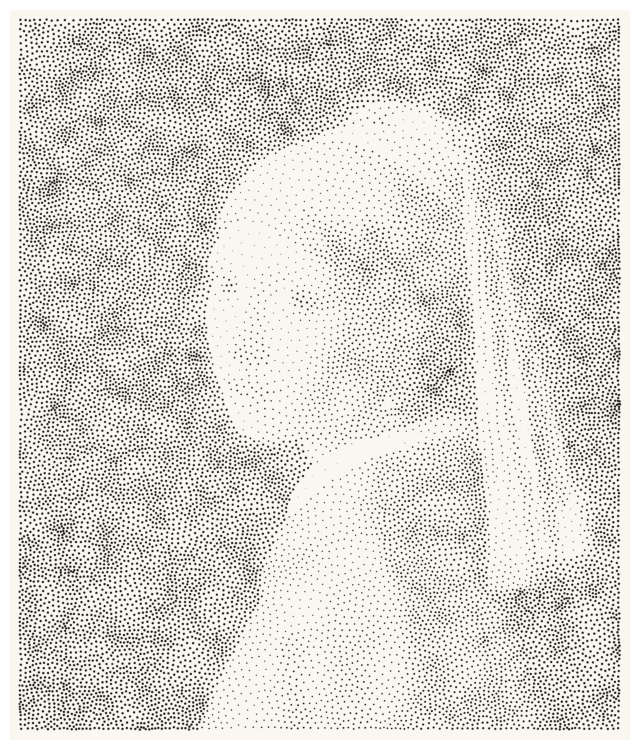

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch11_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(8, 9.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: pictures built from pieces

In 1886, at the last Impressionist exhibition, **Georges Seurat** showed *Un dimanche à la Grande Jatte* (1884–86), three meters of Parisian Sunday assembled from countless small touches of unmixed color. Seurat absorbed the scientists of his day, directly and through the writer Charles Blanc: **Michel Eugène Chevreul**, whose law of simultaneous contrast (1839) described how adjacent colors alter each other, and **Ogden Rood**, whose *Modern Chromatics* (1879) distinguished mixing lights from mixing pigments. The divisionist wager was that dots of pure color, fused by the eye at viewing distance, would give a luminosity that mixing on the palette kills. Critics have quarreled with the optics ever since (optical mixture of pigment dots drifts toward gray, not brilliance), but the discipline held: a continuous world, rebuilt from discrete, countable marks.

The wager itself was ancient. The mosaicists of **Ravenna** had assembled emperors from tesserae by the sixth century: in San Vitale (consecrated 547), Justinian and Theodora face each other across the choir in tens of thousands of glass and stone pieces, each one claiming its small region of the picture. When **Gustav Klimt** traveled to Ravenna in 1903, the gold went straight into his portraits; the mosaic logic, a surface divided into cells, each cell one material, is visible in the Stoclet Frieze and everything golden he made after. Printmakers ran the same logic in monochrome: **stipple engraving**, from Giulio Campagnola's experiments around 1510 to Francesco Bartolozzi's fashionable prints of the eighteenth century, renders tone purely through the spacing and size of dots. And **Chuck Close** built enormous portrait heads cell by cell on a penciled grid from the late 1960s; by the 1980s each cell had become a small abstract painting that dissolves into skin at ten paces.

In 2002 the computer graphics researcher **Adrian Secord** published the modern member of this family: *Weighted Voronoi Stippling*, an algorithm that places dots so evenly, yet so faithfully to an image's tones, that the results pass for a patient engraver's work. It is built from two pieces of honest geometry: the **Voronoi tessellation**, which assigns every location to its nearest dot, and **Lloyd's relaxation**, which repeatedly centers each dot in its own territory. Today we build both pieces by hand, then assemble Secord's machine and aim it at Vermeer.

## Nearest wins

Scatter a few **seed points** on the plane. The **Voronoi cell** of seed $s_i$ is the set of all locations closer to it than to any other seed:

$$V_i = \{\, p \;:\; d(p, s_i) \le d(p, s_j) \ \text{for all } j \,\}$$

(Read the braces aloud: "the set of locations $p$ whose distance $d$ to seed $i$ is at most their distance to any other seed $j$".) The tessellation (Parkettierung) is named after the mathematician Georgy Voronoy (1908), and it needs no drawing instructions at all: the cells simply *happen* wherever the rule is evaluated. So let us evaluate it, brute force, on a pixel grid: `np.meshgrid` from chapter 7 gives every pixel's coordinates, we measure the distance to each seed (straight-line distance is Pythagoras on the coordinate differences, $\sqrt{\Delta x^2 + \Delta y^2}$, exactly the sqrt of squares in the code), and `np.argmin` reports the index of the smallest value, that is, *which seed won that pixel*.

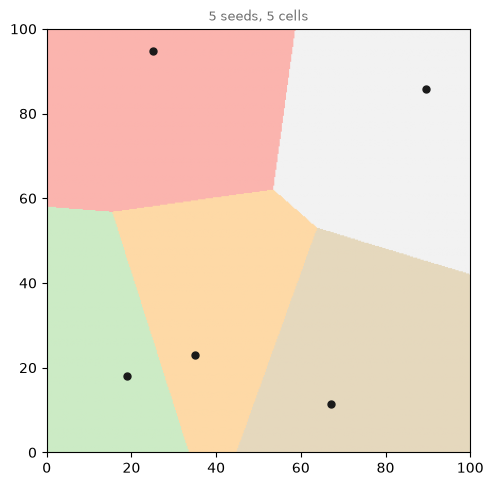

In [2]:
# brute-force Voronoi: every pixel asks "which seed is nearest to me?"
import numpy as np

rng = np.random.default_rng(12)
seeds = rng.uniform(0, 100, size=(5, 2))

grid_x, grid_y = np.meshgrid(np.linspace(0, 100, 400), np.linspace(0, 100, 400))
distances = []
for seed_x, seed_y in seeds:
    distances.append(np.sqrt((grid_x - seed_x)**2 + (grid_y - seed_y)**2))
nearest = np.argmin(np.array(distances), axis=0)    # index of the winning seed

plt.figure(figsize=(5.5, 5.5))
plt.imshow(nearest, cmap="Pastel1", origin="lower", extent=[0, 100, 0, 100])
plt.scatter(seeds[:, 0], seeds[:, 1], color="#1A1A1A", s=25)
plt.title(f"{len(seeds)} seeds, {len(seeds)} cells", fontsize=9,
          color="#6B6B6B")
plt.show()

Straight borders, every border exactly halfway between two seeds: the rule contains its own geometry. Nature evaluates this rule constantly, which is why Voronoi patterns look familiar: dragonfly wings, cracked mud, giraffe patches, foam.

**Try it.** Change the seed of `rng`, or use `size=(12, 2)` for twelve seeds. The code never mentions the number five anywhere else; the picture just follows the points.

Connect every pair of seeds whose cells share a border and you get the **Delaunay triangulation**, the tessellation's dual, named after Boris Delaunay (1934), who dedicated the paper to Voronoy's memory. Computing cells fast (without touching every pixel) takes a clever sweep algorithm that is not today's lesson; the brute force above was the lesson. So from here we let scipy do the geometry:

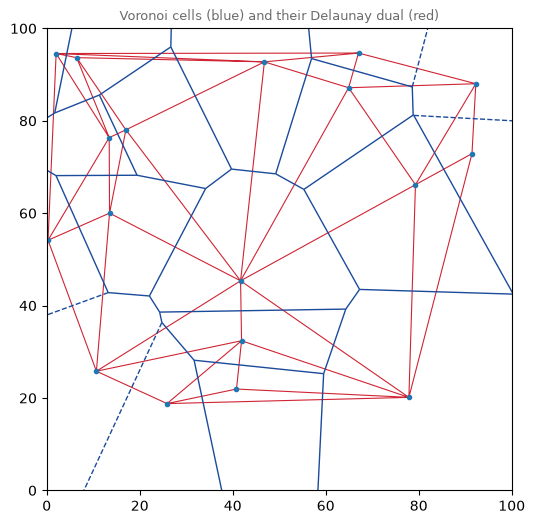

In [3]:
# the library version, with its dual: Voronoi cells and Delaunay triangles
from scipy.spatial import Voronoi, Delaunay, voronoi_plot_2d

points = rng.uniform(0, 100, size=(18, 2))
vor = Voronoi(points)
tri = Delaunay(points)

fig, ax = plt.subplots(figsize=(6, 6))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="#1B4B9B")
ax.triplot(points[:, 0], points[:, 1], tri.simplices, color="#D02433",
           linewidth=0.8)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_title("Voronoi cells (blue) and their Delaunay dual (red)",
             fontsize=9, color="#6B6B6B")
plt.show()

## Stained glass from random points

For artwork we render the cells ourselves: fill each one with a palette color and lead the edges in dark, and the tessellation becomes a window. Two practical details. First, scipy's `vor.point_region` tells us which region belongs to which seed, and `vor.vertices[region]` returns that cell's corner points, ready for `ax.fill`. Second, the outermost cells are infinite (they stretch to the horizon), which ruins polygon drawing; the standard trick is to add a **ring of helper seeds** far outside the canvas. The helpers absorb the infinities, every *real* cell becomes a finite polygon, and we simply never draw the helpers.

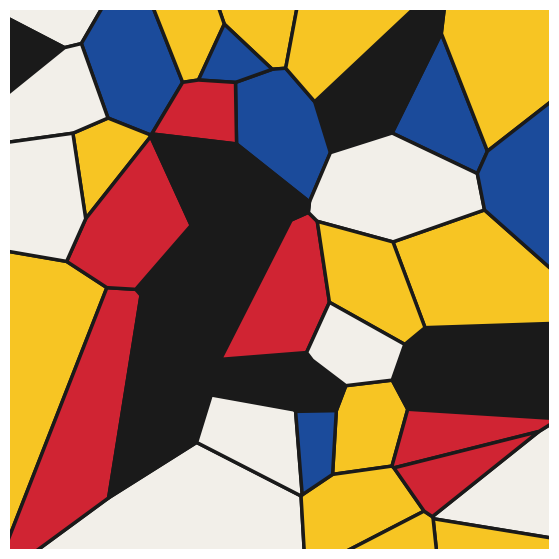

In [4]:
# stained glass: fill each cell with a palette color, lead the edges in dark
import sys
sys.path.append("..")
from agap.helpers import PALETTES, save_artwork

def stained_glass(n_cells, palette_name, seed, size=100, figsize=7):
    rng = np.random.default_rng(seed)
    inner = rng.uniform(0, size, size=(n_cells, 2))
    angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
    ring = size / 2 + size * 1.5 * np.stack([np.cos(angles), np.sin(angles)],
                                            axis=1)
    vor = Voronoi(np.vstack([inner, ring]))     # the ring tames the border cells
    palette = PALETTES[palette_name]
    fig, ax = plt.subplots(figsize=(figsize, figsize))
    for i in range(n_cells):
        region = vor.regions[vor.point_region[i]]
        if -1 in region:          # still infinite despite the ring: skip it
            continue
        corners = vor.vertices[region]
        color = palette[int(rng.integers(len(palette)))]
        ax.fill(corners[:, 0], corners[:, 1], color=color,
                edgecolor="#1A1A1A", linewidth=2.5)
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

art_1 = stained_glass(40, "bauhaus", seed=5)

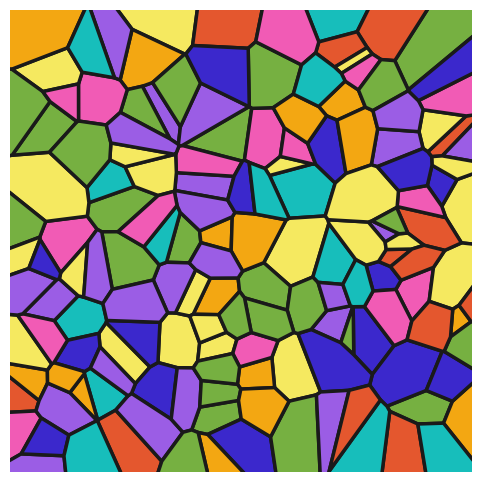

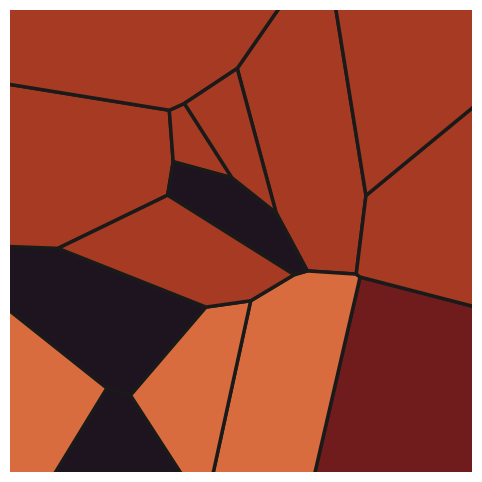

In [5]:
# two more windows: dense Kelly spectrum, sparse Rothko gloom
art_2 = stained_glass(150, "kelly", seed=8, figsize=6)
art_3 = stained_glass(15, "rothko_dark", seed=2, figsize=6)

**Look and compare.** Forty Bauhaus cells read as a cheerful church window; a hundred and fifty Kelly cells shimmer like confetti; fifteen Rothko cells become heavy, almost architectural. The code is identical. Is it the *count* or the *palette* doing the emotional work here? Try swapping them (15 kelly cells, 150 rothko cells) before you answer.

## Points that space themselves

Look again at any of the windows above: random points clump and leave voids (chapter 2 taught us uniform randomness is lumpy). Mosaic and stippling both want the opposite: **evenness without rigidity**, dots that keep polite distances yet stand in no rows. The classic recipe is **Lloyd's relaxation**, proposed by Stuart Lloyd at Bell Labs in 1957 (and only properly published in 1982):

1. compute every point's Voronoi cell,
2. move each point to its cell's **centroid** (Schwerpunkt), the average of all locations in the cell,
3. repeat.

Crowded points sit in small cells and get pushed apart; lonely points own huge cells and get pulled toward the middle of their emptiness. For the centroid we recycle the brute-force idea from the opening: assign every pixel of a fine grid to its nearest point, then average the pixel coordinates that each point won. (The `[:, None, :]` indexing below inserts a brand-new axis so that every pixel meets every point in one broadcast subtraction: chapter 10's broadcasting idea, taken one step further.)

In [6]:
# one Lloyd step: every point moves to the centroid of its Voronoi cell
def lloyd_step(points, size=100, resolution=150):
    coords = np.linspace(0, size, resolution)
    grid_x, grid_y = np.meshgrid(coords, coords)
    pixels = np.stack([grid_x.ravel(), grid_y.ravel()], axis=1)
    gaps = pixels[:, None, :] - points[None, :, :]     # every pixel, every point
    # np.linalg.norm measures each gap vector's length
    nearest = np.argmin(np.linalg.norm(gaps, axis=2), axis=1)
    moved = points.copy()
    for i in range(len(points)):
        won = pixels[nearest == i]
        if len(won) > 0:
            moved[i] = won.mean(axis=0)
    return moved

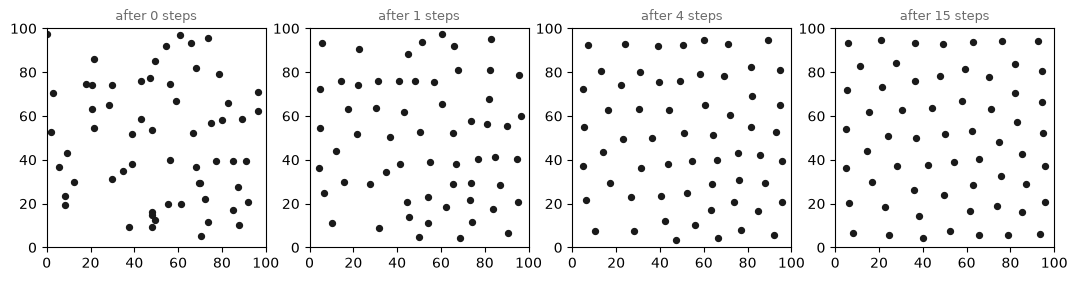

In [7]:
# watch evenness emerge: the same 60 points after 0, 1, 4 and 15 steps
rng = np.random.default_rng(3)
pts = rng.uniform(0, 100, size=(60, 2))

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
steps_done = 0
for ax, target in zip(axes, [0, 1, 4, 15]):
    while steps_done < target:
        pts = lloyd_step(pts)
        steps_done += 1
    ax.scatter(pts[:, 0], pts[:, 1], s=18, color="#1A1A1A")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.set_title(f"after {target} steps", fontsize=9, color="#6B6B6B")
plt.show()

Fifteen steps turn a lumpy scatter into something a jeweler could have laid out: even, but nowhere gridded. This texture has a name, **blue noise**, borrowed from audio engineering (noise with mostly high frequencies: no large-scale clumps), and it is precious in graphics precisely because human eyes forgive it. Compare it mentally to chapter 2's grids: this is a third kind of arrangement, neither order nor disorder.

## Ink where the painting is dark

Now the payoff. Johannes Vermeer's *Girl with a Pearl Earring* (c. 1665, Mauritshuis, Den Haag) is mostly darkness with one luminous face, dramatic stippling material. The plan: convert the painting to grayscale, read `darkness = 1 - brightness` as a *probability map*, and scatter dots by **rejection sampling**: propose a random location, keep it with probability equal to the darkness underneath, chapter 2's weighted choice gone continuous.

The raw map needs two engraver's adjustments first, and they are worth naming because every stippler makes them. This painting's background is *near-black everywhere*, so left alone it would swallow the entire dot budget and the girl would become empty negative space (try it later: sample from plain `darkness` and watch it happen). So we **cap** the darkness with `np.clip`, above the cap, darker buys no more ink, and apply a **gamma** of 1.4, a small power that thins the midtones so the face keeps its light. Tone in, ink out, but through a curve the artist chose.

In [8]:
# load the Vermeer small and in grayscale; darkness becomes probability
from PIL import Image

original = Image.open("../assets/images/vermeer_pearl_earring.jpg")
scale_w = 480
scale_h = int(original.height * scale_w / original.width)
gray = np.asarray(original.convert("L").resize((scale_w, scale_h))) / 255
darkness = 1 - gray
tone = np.clip(darkness, 0, 0.82)**1.4     # cap the blacks, thin the midtones

def sample_by_map(n_dots, probability, rng):
    height, width = probability.shape
    dots = []
    while len(dots) < n_dots:
        x, y = rng.uniform(0, width), rng.uniform(0, height)
        if rng.random() < probability[int(y), int(x)]:
            dots.append([x, y])
    return np.array(dots)

rng = np.random.default_rng(12)
dots = sample_by_map(8000, tone, rng)
print("dots placed:", len(dots))

dots placed: 8000


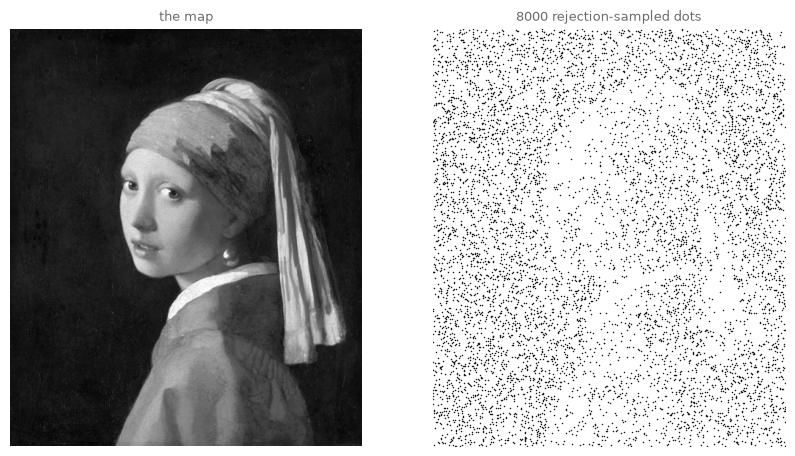

In [9]:
# the raw sample: faithful to the tones, but clumpy as all randomness is
fig, axes = plt.subplots(1, 2, figsize=(10, 6.2))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("the map", fontsize=9, color="#6B6B6B")
axes[1].scatter(dots[:, 0], dots[:, 1], s=1.2, color="#1A1A1A", linewidths=0)
axes[1].set_xlim(0, scale_w)
axes[1].set_ylim(scale_h, 0)
axes[1].set_aspect("equal")
axes[1].set_title("8000 rejection-sampled dots", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

She is already there, but the dots clump and leave scratchy voids: raw randomness, chapter 2's oldest lesson. Secord's contribution is the cure: run Lloyd's relaxation, but compute each centroid **weighted by the tone map**,

$$c_i = \frac{\sum_{p \in V_i} w(p)\; p}{\sum_{p \in V_i} w(p)},$$

so points spread evenly *within* the tonal structure instead of erasing it: dark regions keep their dense crowds, every crowd becomes orderly. (The formula is less than it looks: read $\sum_{p \in V_i}$ as "add up, one term per pixel $p$ of cell $i$"; the whole thing is chapter 0's mean, with each pixel counted in proportion to its weight $w(p)$.)

Two speed tools, because our brute-force distance table would now be 8000 points times roughly a quarter of a million pixels. `scipy.spatial.cKDTree` is this chapter's one true black box: a search tree that answers "which of these 8000 points is nearest to this pixel?" thousands of times faster than our table (the idea inside: recursively split the plane so most points never need checking). And `np.bincount(nearest, weights=w)` sums the weights landing on each point index in one call, our centroid sums without a Python loop.

In [10]:
# weighted Lloyd: centroids weighted by image darkness, at KD-tree speed
# (black box: skim the code; the idea is in the text above)
from scipy.spatial import cKDTree

def weighted_lloyd(dots, weight_map, iterations=30):
    height, width = weight_map.shape
    grid_x, grid_y = np.meshgrid(np.arange(width), np.arange(height))
    pixels = np.stack([grid_x.ravel(), grid_y.ravel()], axis=1).astype(float)
    weights = weight_map.ravel() + 1e-9
    moved = dots.copy()
    for iteration in range(iterations):
        nearest = cKDTree(moved).query(pixels)[1]
        weight_sums = np.bincount(nearest, weights=weights, minlength=len(moved))
        x_sums = np.bincount(nearest, weights=weights * pixels[:, 0],
                             minlength=len(moved))
        y_sums = np.bincount(nearest, weights=weights * pixels[:, 1],
                             minlength=len(moved))
        won_pixels = weight_sums > 0
        moved[won_pixels, 0] = x_sums[won_pixels] / weight_sums[won_pixels]
        moved[won_pixels, 1] = y_sums[won_pixels] / weight_sums[won_pixels]
    return moved

dots = weighted_lloyd(dots, tone, iterations=40)
print("40 iterations of weighted Lloyd done")

40 iterations of weighted Lloyd done


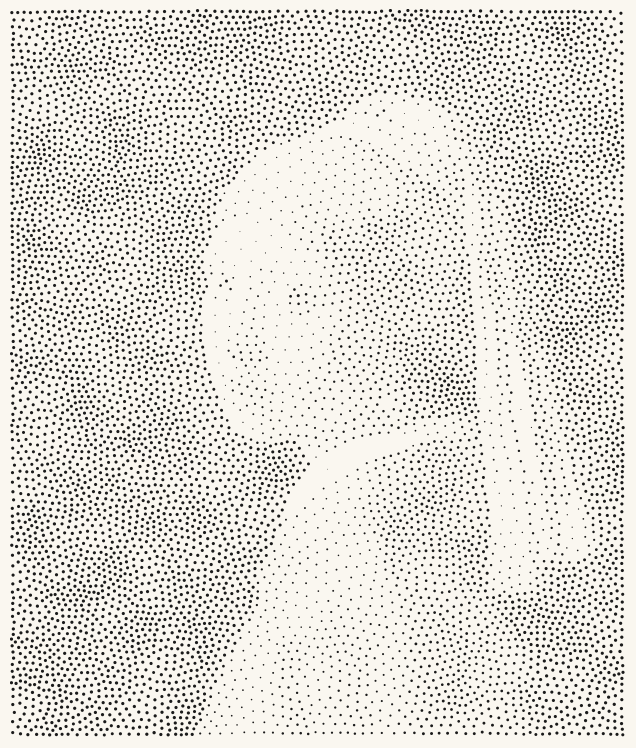

In [11]:
# render: one ink dot per point, its size following the local darkness
from agap.helpers import PAPER

def stipple_art(dots, darkness, dot_scale=6.0, ink="#1A1A1A", paper=PAPER,
                figsize=8):
    height, width = darkness.shape
    # two index arrays pick one pixel per dot (rows = y, columns = x)
    local = darkness[dots[:, 1].astype(int), dots[:, 0].astype(int)]
    fig, ax = plt.subplots(figsize=(figsize, figsize * height / width))
    fig.patch.set_facecolor(paper)
    ax.set_facecolor(paper)
    ax.scatter(dots[:, 0], dots[:, 1], s=dot_scale * local**1.5 + 0.15,
               color=ink, linewidths=0)
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

art_stipple = stipple_art(dots, darkness)

**Look and compare** this against the raw sample two figures up: same painting, same number of dots. The relaxed version breathes; tone is carried by dot *density and size* while the spacing stays calm. That calm is the blue noise, and it is what separates machine stippling that looks engraved from machine stippling that looks like static.

## Second machine: a stained-glass wave

*(If the session is running long, this second machine reads just as well at home.)*

The stippler subtracts color; the mosaicist keeps it. For a Voronoi mosaic of Hokusai's *Great Wave* (chapter 7's old acquaintance) we want seeds where the image is *busiest*, and busyness is measurable: `np.gradient` returns how fast brightness changes at every pixel, and the length of that change vector is the **edge magnitude**. (That single line is a preview: chapter 12 is entirely about such filters.) We reuse `sample_by_map` unchanged, feeding it edges instead of darkness: the sampler never cared what the map *meant*.

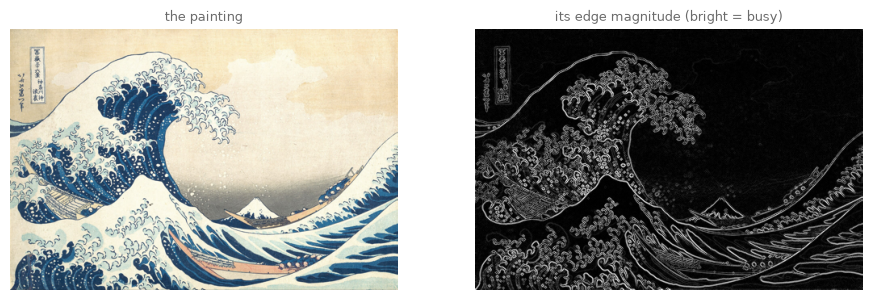

In [12]:
# where is the wave busiest? edge magnitude will place our seeds
wave = np.asarray(Image.open("../assets/images/hokusai_wave.jpg")
                  .resize((480, 323))) / 255
wave_gray = wave.mean(axis=2)      # average over the color axis: grayscale
d_row, d_col = np.gradient(wave_gray)
edge_map = np.sqrt(d_row**2 + d_col**2)
edge_map = edge_map / edge_map.max()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
axes[0].imshow(wave)
axes[0].set_title("the painting", fontsize=9, color="#6B6B6B")
axes[1].imshow(edge_map, cmap="gray")
axes[1].set_title("its edge magnitude (bright = busy)", fontsize=9,
                  color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

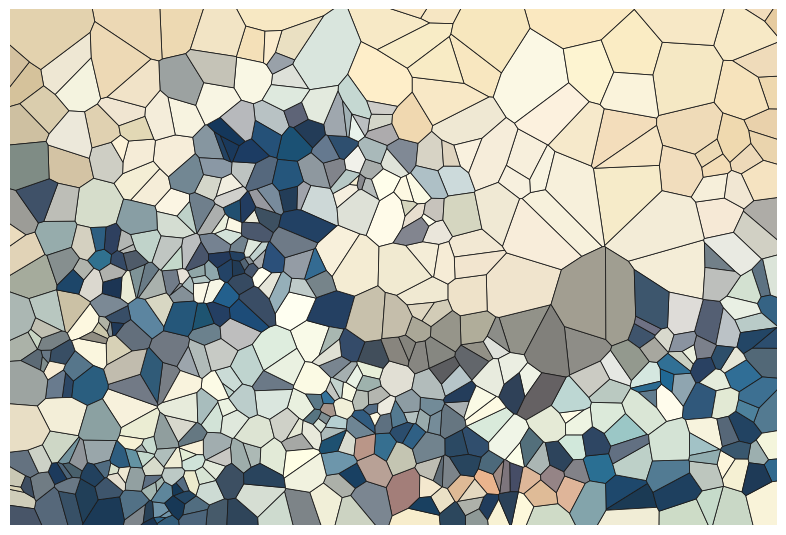

In [13]:
# the Great Wave as stained glass: small cells where the drawing is busy
rng = np.random.default_rng(19)
# the +0.02 floor grants the calm sky a few seeds too
seeds = sample_by_map(600, edge_map * 0.9 + 0.02, rng)
angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
# helper ring around the canvas center (240, 161), far outside at radius 900
ring = np.stack([240 + 900 * np.cos(angles), 161 + 900 * np.sin(angles)],
                axis=1)
vor = Voronoi(np.vstack([seeds, ring]))

fig, ax = plt.subplots(figsize=(10, 6.7))
for i in range(len(seeds)):
    region = vor.regions[vor.point_region[i]]
    if -1 in region:
        continue
    corners = vor.vertices[region]
    color = wave[int(seeds[i, 1]), int(seeds[i, 0])]
    ax.fill(corners[:, 0], corners[:, 1], color=color,
            edgecolor="#1A1A1A", linewidth=0.6)
ax.set_xlim(0, 480)
ax.set_ylim(323, 0)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
art_wave = fig

Each cell wears the painting's color at its own seed, so dense seeding gives the wave's crest hundreds of small sharp facets while the empty sky stays in a few broad panes: detail spent exactly where the drawing spends it. Ravenna's mosaicists sized their tesserae the same way, small in the faces, large in the gold.

**Try it.** Lower the 600 to 80 and the wave dissolves toward abstraction; raise it to 2000 (a few extra seconds) and the mosaic approaches the print itself. Somewhere in between is the count where the picture is *most interesting*, which is an aesthetic judgment no formula makes for you.

## Export your artwork

Stipple or mosaic, Vermeer or your own image (drop a file into `assets/images/` and reuse the loading pattern above; portraits with dark grounds stipple magnificently). Adjust `dot_scale`, ink and paper, replace `yourname`, run. As always, the sampling seed is yours to change: every seed is a different swarm of dots.

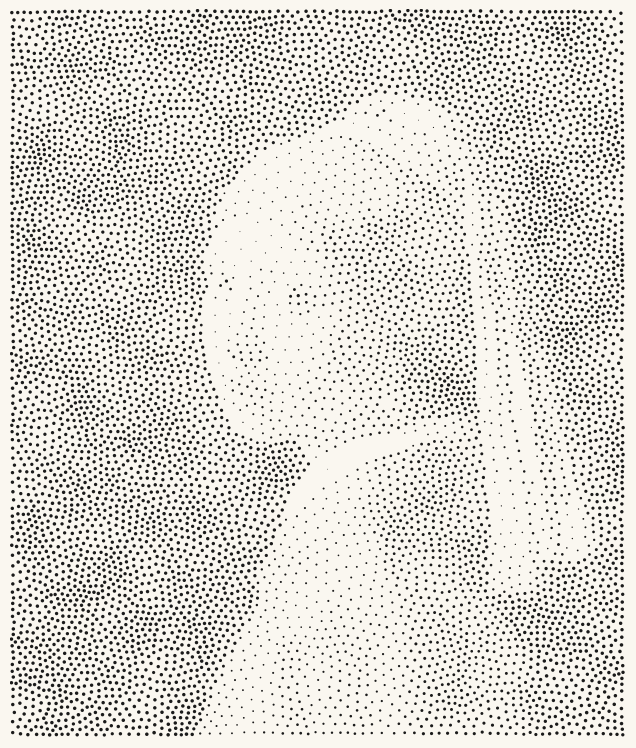

saved: assets/outputs/ch11_yourname.png


In [14]:
# save YOUR artwork: pick dots, scale, ink and paper, replace 'yourname'
my_artwork = stipple_art(dots, darkness, dot_scale=7.0)
saved_path = save_artwork(my_artwork, "yourname", chapter=11)

## Exercises

**(a) Parameter exploration: when does she appear?** Rerun the stippling pipeline (sample, relax, render) with 1000, 5000 and 20000 dots. At which count do you first *recognize* the girl, and at which does the earring itself materialize? Note that the Lloyd stage matters too: compare 20000 dots with 5 iterations against 5000 dots with 40, and decide which budget buys more likeness.

**(b) Code modification: stipples in color.** Give every dot the *painting's own color* at its position instead of black ink. Load the color version at the same small size, index it with the dot coordinates, and pass the result to `plt.scatter`'s `c=` argument. One aesthetic decision matters: on cream paper, colored dots look washed out; give them a dark room instead.

<details><summary>Solution</summary>

```python
color_small = np.asarray(original.convert("RGB")
                         .resize((scale_w, scale_h))) / 255
xs = dots[:, 0].astype(int)
ys = dots[:, 1].astype(int)
dot_colors = color_small[ys, xs]        # each dot samples its own pixel
local = darkness[ys, xs]

night = "#14121C"
fig, ax = plt.subplots(figsize=(8, 8 * scale_h / scale_w))
fig.patch.set_facecolor(night)
ax.set_facecolor(night)
ax.scatter(dots[:, 0], dots[:, 1], s=7 * local**2 + 0.3, c=dot_colors,
           linewidths=0)
ax.set_xlim(0, scale_w)
ax.set_ylim(scale_h, 0)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
```

On the dark ground the logic inverts beautifully: Vermeer's shadows melt into the paper and the *lit* dots carry the image, less Seurat, more mosaic by candlelight. (`color_small[ys, xs]` picks one pixel per dot in a single indexing call, chapter 5's numpy indexing earning its keep.)
</details>

**(c) Creative challenge: the true mosaic.** In the wave mosaic, each cell took the color of a single pixel, its seed. Upgrade it: fill each cell with the **mean color of all the pixels inside it**. You already own every tool: assign pixels to seeds with `cKDTree`, then average per cell with `np.bincount` once per color channel (or a loop over cells, slower and fine). Compare against the seed-sampled version: the mean-color mosaic is calmer, almost woven. Then push the cell count down until the painting sits exactly at the edge of recognizability, and consider: Chuck Close spent months per painting deciding what goes into each cell; what did your `mean` just decide for you?

## Further reading

- Adrian Secord, "Weighted Voronoi Stippling", *Proceedings of NPAR 2002*: seven readable pages; our pipeline is his Section 3.
- Robert L. Herbert, *Georges Seurat, 1859–1891* (Metropolitan Museum of Art, 1991): the great Seurat catalogue, with the divisionist color theory taken seriously and skeptically.
- John Gage, *Colour and Culture* (1993), chapter on the scientific color theories of the nineteenth century: what painters actually took from Chevreul and Rood.
- The [scipy.spatial documentation](https://docs.scipy.org/doc/scipy/reference/spatial.html): Voronoi, Delaunay and KD-trees, with pictures; the tools of today, formally introduced.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: eighteen thousand dots, fifty relaxation steps, well under a minute. It runs automatically with *Restart & Run All*. At home, try 30000 dots with `dot_scale` around 3.

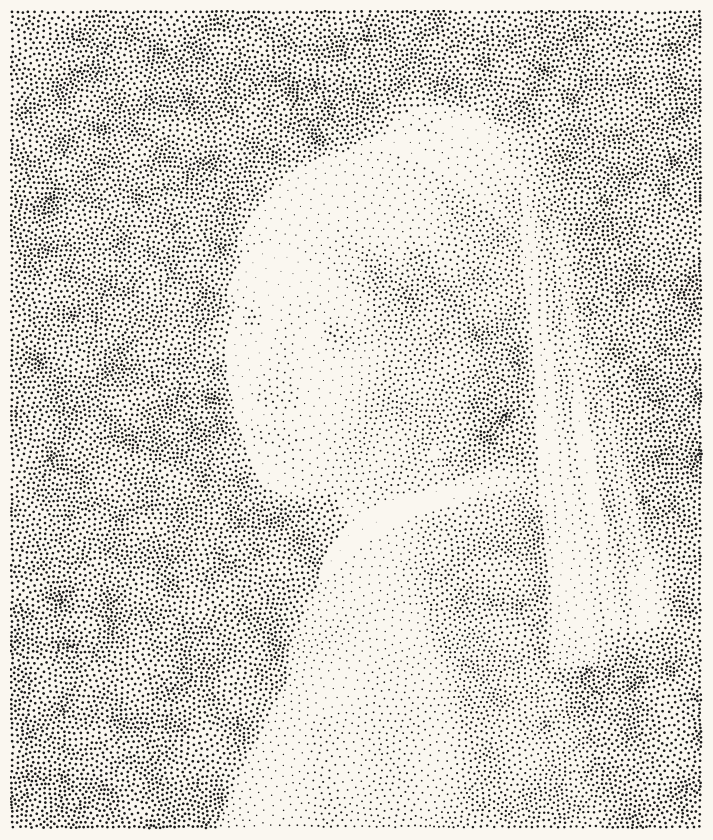

saved: assets/outputs/ch11_showpiece.png


In [15]:
# regenerate this chapter's showpiece: the stippled Vermeer, dense and calm
rng_show = np.random.default_rng(1665)
show_dots = sample_by_map(18000, tone, rng_show)
show_dots = weighted_lloyd(show_dots, tone, iterations=50)
showpiece = stipple_art(show_dots, darkness, dot_scale=4.2, figsize=9)
saved_path = save_artwork(showpiece, "showpiece", chapter=11)